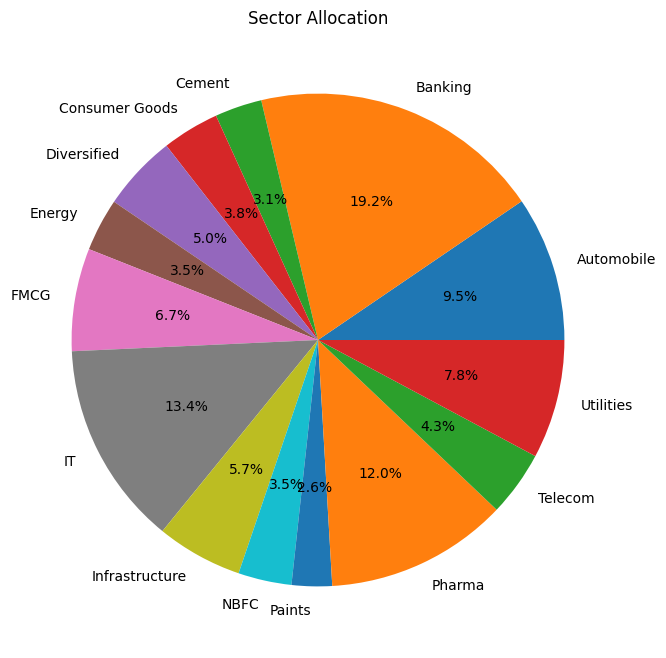

In [46]:
plt.figure(figsize=(8,8))

sector_summary = (
    holdings.groupby("sector")["weight_pct"]
            .sum()
)

plt.pie(
    sector_summary,
    labels=sector_summary.index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")

plt.savefig("../reports/sector_allocation.png")

plt.show()

In [45]:
holdings = pd.read_csv(
    BASE_DIR / "Data" / "raw" / "09_portfolio_holdings.csv"
)

print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


['amfi_code', 'date', 'nav']


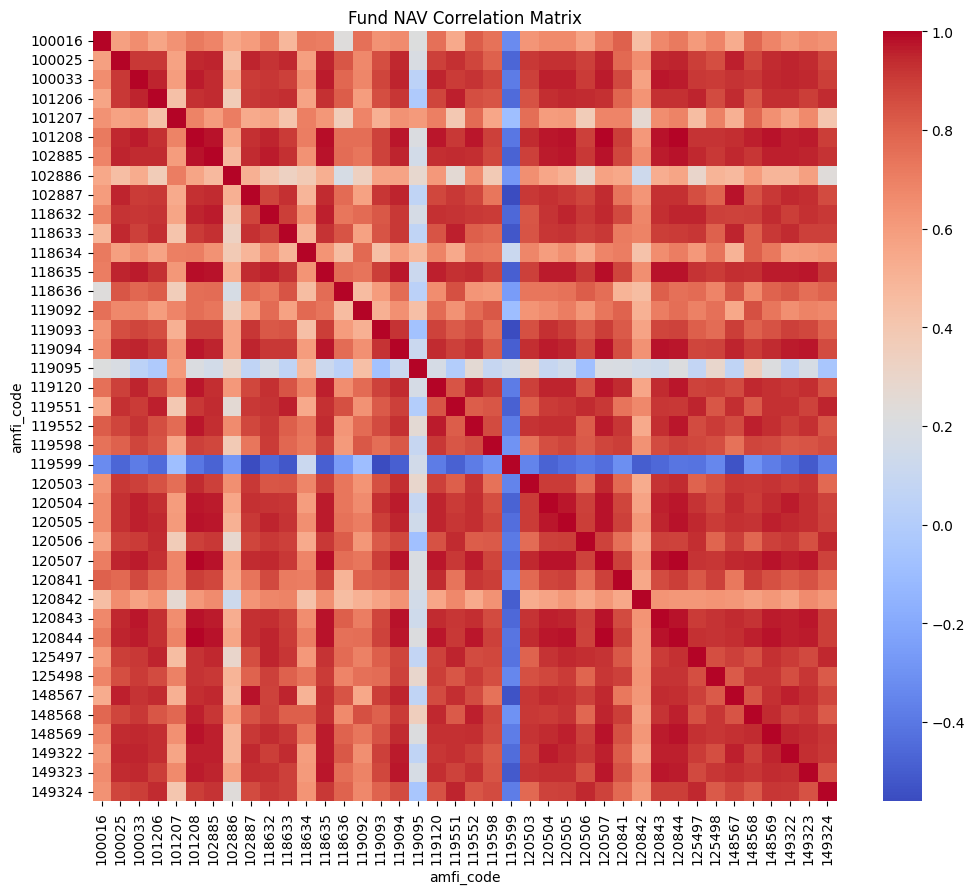

In [44]:
print(nav.columns.tolist())

nav["date"] = pd.to_datetime(nav["date"])

pivot = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

corr = pivot.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Fund NAV Correlation Matrix")

plt.savefig("../reports/correlation_matrix.png")

plt.show()

In [39]:
folio = pd.read_csv(
    BASE_DIR / "Data" / "raw" / "06_industry_folio_count.csv"
)

print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


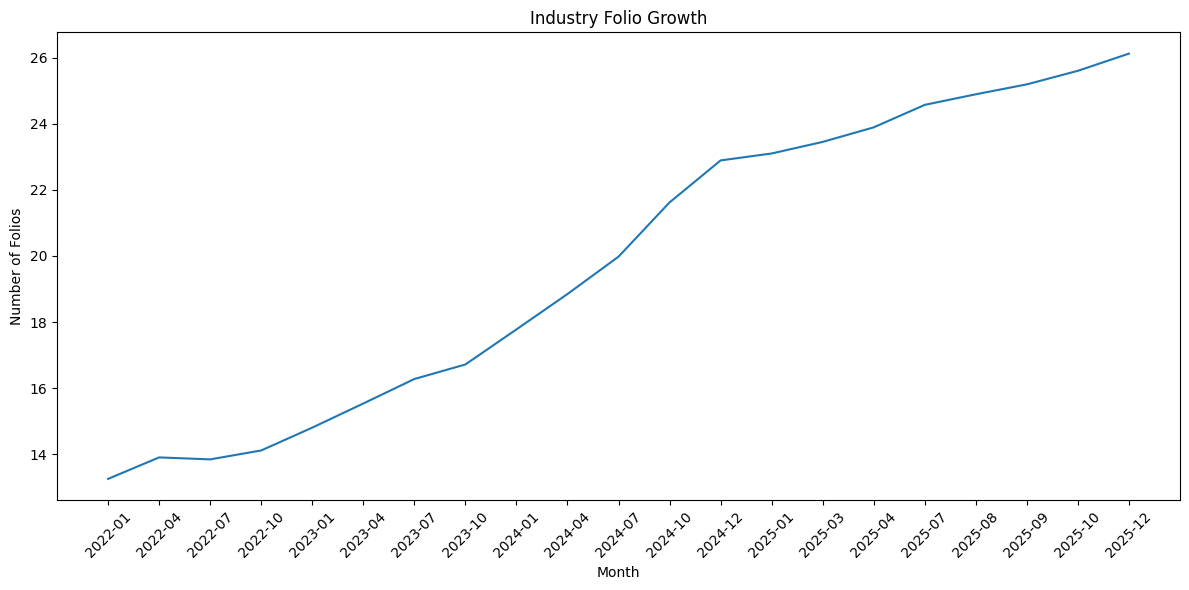

In [40]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Number of Folios")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/folio_growth.png")
plt.show()


In [35]:
folio = pd.read_csv(
    BASE_DIR / "Data" / "raw" / "06_industry_folio_count.csv"
)

print(folio.columns.tolist())
folio.head()

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


<StringArray>
['T30', 'B30']
Length: 2, dtype: str


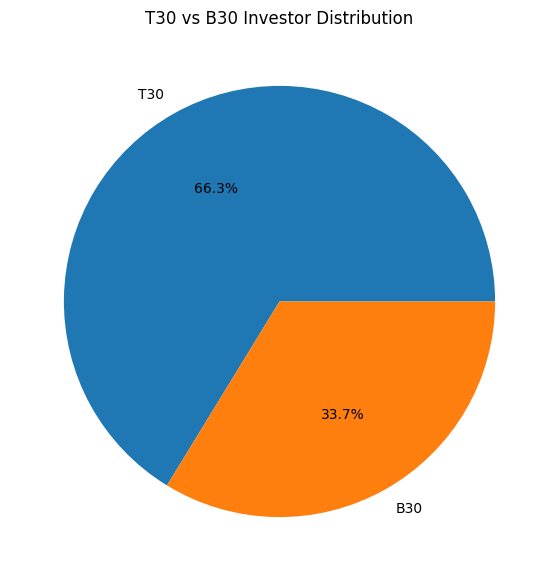

In [34]:
print(txn["city_tier"].unique())

plt.figure(figsize=(7,7))

txn["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig("../reports/t30_b30_distribution.png")

plt.show()

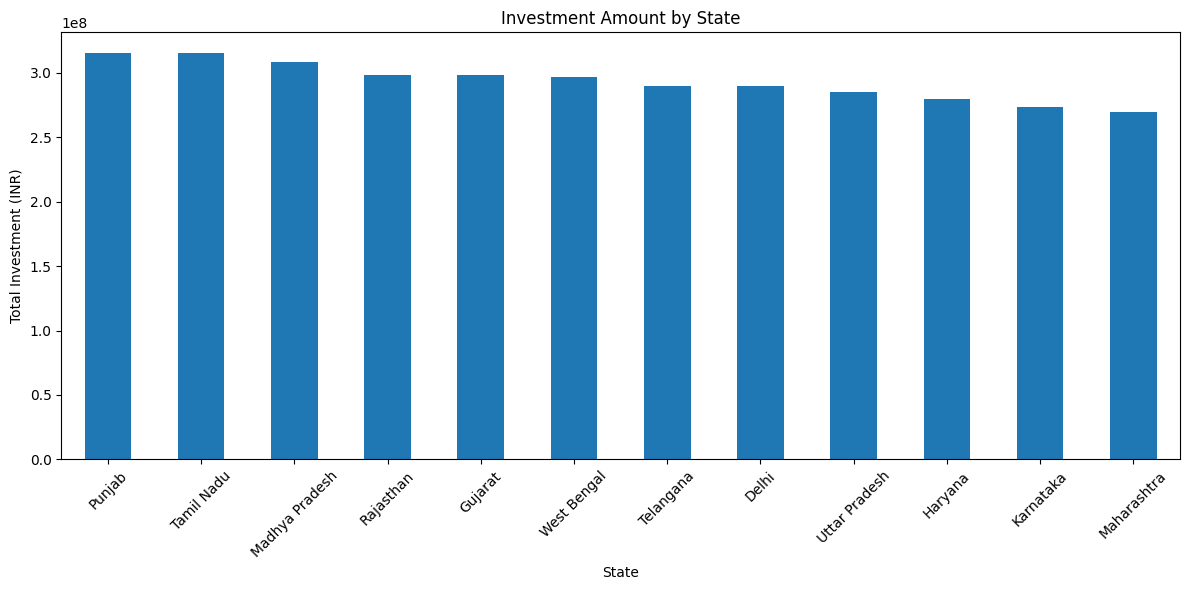

In [32]:
state_amount = (
    txn.groupby("state")["amount_inr"]
       .sum()
       .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

state_amount.plot(kind="bar")

plt.title("Investment Amount by State")
plt.xlabel("State")
plt.ylabel("Total Investment (INR)")
plt.xticks(rotation=45)

plt.tight_layout()


plt.savefig("../reports/state_wise_investment.png")


plt.show()

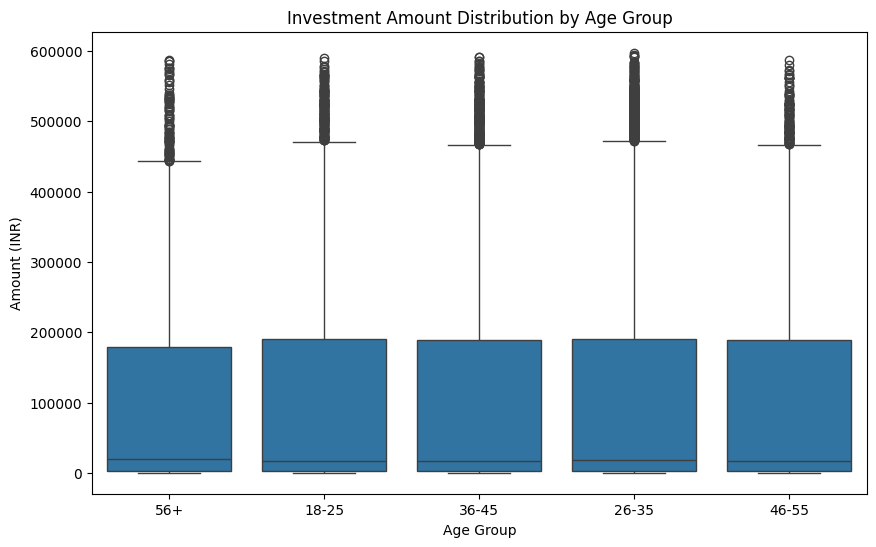

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure(figsize=(10,6))

BASE_DIR = Path.cwd().parent 

sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")


plt.savefig("../reports/sip_amount_by_age.png")

plt.show()

In [27]:
print(txn.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [21]:
print("Investor Transactions")
print(txn.columns.tolist())

print("\nPortfolio Holdings")
holdings = pd.read_csv(BASE_DIR / "Data" / "raw" / "09_portfolio_holdings.csv")
print(holdings.columns.tolist())

print("\nIndustry Folio Count")
folio = pd.read_csv(BASE_DIR / "Data" / "raw" / "06_industry_folio_count.csv")
print(folio.columns.tolist())

print("\nNAV History")
print(nav.columns.tolist())

Investor Transactions
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Portfolio Holdings
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Industry Folio Count
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

NAV History
['amfi_code', 'date', 'nav']


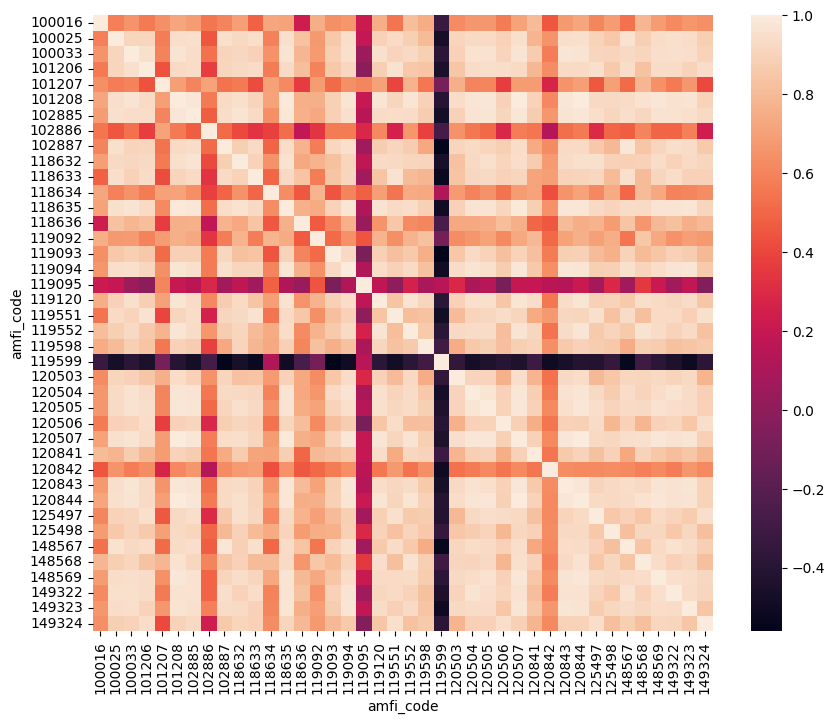

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent 

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

corr = pivot.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr)

plt.show()

plt.savefig("../reports/correlation_matrix.png")

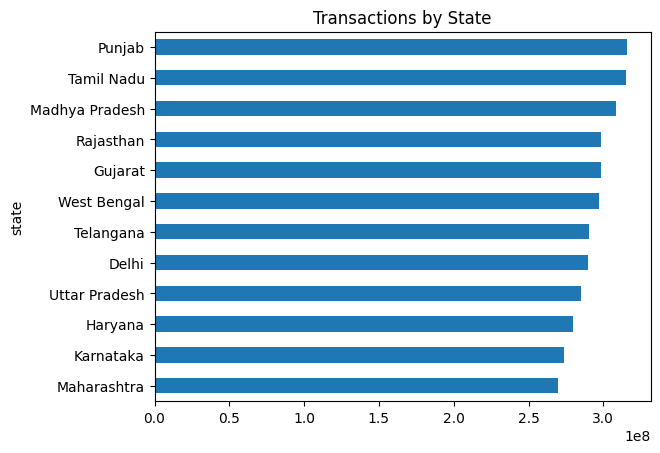

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

state_data = (
    txn.groupby("state")
       ["amount_inr"]
       .sum()
       .sort_values()
)

state_data.plot(kind="barh")

plt.title("Transactions by State")

plt.show()

plt.savefig("../reports/state_transactions.png")


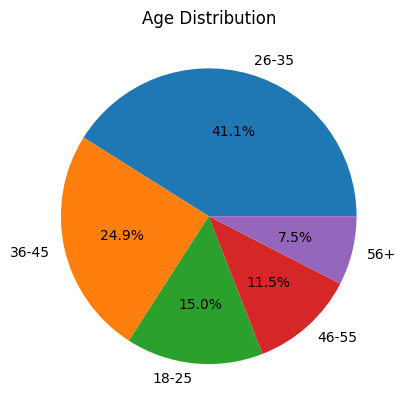

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

nav = pd.read_csv(...)
txn = pd.read_csv(...)

BASE_DIR = Path.cwd().parent 

txn["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Age Distribution")
plt.show()
plt.savefig(BASE_DIR / "Reports" / "age_distribution.png")


In [9]:
plt.savefig("../reports/sip_trend.png")
plt.show()


<Figure size 640x480 with 0 Axes>

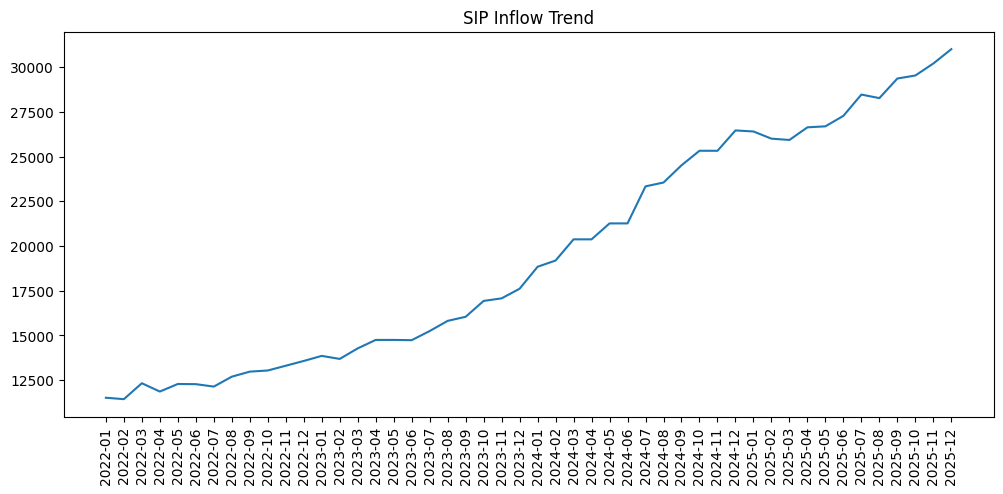

In [ ]:
import matplotlib.pyplot as plt
sip = pd.read_csv(
    BASE_DIR/"Data/raw/04_monthly_sip_inflows.csv"
)

plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.xticks(rotation=90)
plt.title("SIP Inflow Trend")
plt.show()

In [4]:
plt.savefig("../reports/nav_trend.png")


<Figure size 640x480 with 0 Axes>

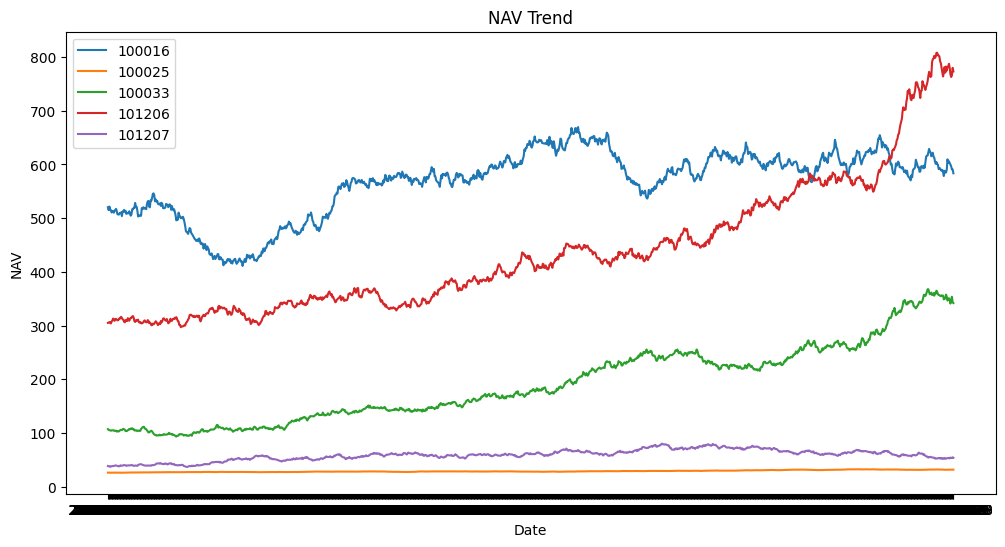

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

for code in nav["amfi_code"].unique()[:5]:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=code)

plt.title("NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.savefig(BASE_DIR / "Reports" / "nav_trend.png")

plt.show()

In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd().parent

fund = pd.read_csv(BASE_DIR / "Data" / "processed" / "fund_master_clean.csv")
nav = pd.read_csv(BASE_DIR / "Data" / "processed" / "nav_history_clean.csv")
txn = pd.read_csv(BASE_DIR / "Data" / "processed" / "investor_transactions_clean.csv")
perf = pd.read_csv(BASE_DIR / "Data" / "processed" / "scheme_performance_clean.csv")